
# **Lab #1: การจัดการข้อมูลพื้นฐาน**
## **วัตถุประสงค์**
1. เรียนรู้การใช้งาน Python เบื้องต้นสำหรับการจัดการข้อมูล
2. เรียนรู้การใช้ไลบรารีสำคัญ เช่น Pandas และ GeoPandas
3. เรียนรู้การอ่าน/เขียนและสำรวจข้อมูลทางภูมิศาสตร์ (GeoData)

---
หมายเหตุ บางครั้งอาจจะเจอ Bug. ขอจงอย่าย่อท้อ ให้ใช้ทรัพยากรที่มีอยู่ในการจัดการแก้ไขปัญหา เช่น  Gemini หรือ ChatGPT แต่ทั้งนี้ต้องทำความเข้าใจกับคำตอบที่ได้ เพราะบางครั้ง AI ก็ให้คำตอบแบบงงๆ



## **1. การเริ่มต้นใช้งาน Google Colab**
### **1.1 เชื่อมต่อ Google Drive**
ก่อนอื่น ให้เชื่อมต่อ Google Drive เพื่อจัดเก็บข้อมูลของคุณ
    

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



### **1.2 ติดตั้งไลบรารีที่จำเป็น**
ติดตั้งไลบรารีที่จำเป็นสำหรับการจัดการข้อมูลและการวิเคราะห์ข้อมูลภูมิศาสตร์
    

In [31]:

!pip install pandas geopandas matplotlib



## **2. การจัดการข้อมูลตารางด้วย Pandas**
### **2.1 สร้าง DataFrame ตัวอย่าง**
ลองสร้าง DataFrame ข้อมูลประชากรของประเทศในภูมิภาค ASEAN
    

In [32]:

import pandas as pd

# สร้าง DataFrame ตัวอย่าง
data = {
    'ประเทศ': ['ไทย', 'ลาว', 'กัมพูชา', 'เวียดนาม'],
    'ประชากร (ล้าน)': [69.8, 7.1, 16.5, 97.3],
    'พื้นที่ (ตร.กม.)': [513120, 236800, 181035, 331210]
}
df = pd.DataFrame(data)

# แสดงข้อมูล
print(df)

# คำนวณความหนาแน่นประชากร
df['ความหนาแน่นประชากร (คน/ตร.กม.)'] = df['ประชากร (ล้าน)'] * 1_000_000 / df['พื้นที่ (ตร.กม.)']
print(df)


     ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)
0       ไทย            69.8            513120
1       ลาว             7.1            236800
2   กัมพูชา            16.5            181035
3  เวียดนาม            97.3            331210
     ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)  ความหนาแน่นประชากร (คน/ตร.กม.)
0       ไทย            69.8            513120                      136.030558
1       ลาว             7.1            236800                       29.983108
2   กัมพูชา            16.5            181035                       91.142597
3  เวียดนาม            97.3            331210                      293.771323



### **2.2 การอ่านไฟล์ข้อมูล CSV**
- ให้นักศึกษาหาข้อมูลที่น่าสนใจในรูปแบบ  CSV
- โหลด File .csv เข้า google drive ของนักศึกษา
- จากนั้นให้ไปดูใน file_path ในรูป โฟลเดอร์ ด้านซ้ายบน
    

In [33]:
 from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import pandas as pd # Import the pandas library

# ตัวอย่างการอ่านไฟล์ CSV
file_path = '/content/drive/MyDrive/Lab1 GE234/data.csv'
geo_df = pd.read_csv(file_path)

# ตรวจสอบข้อมูล
print(geo_df.head())
print(geo_df.info())

   Year Phuket visitor Phuket Revenue (m baht)
0  1988        884,293                     NaN
1  1989        971,683                6,705.89
2  1990      1,254,215                8,574.27
3  1991      1,208,594               10,699.99
4  1992      1,633,496               33,891.17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Year                     37 non-null     int64 
 1   Phuket visitor           37 non-null     object
 2   Phuket Revenue (m baht)  36 non-null     object
dtypes: int64(1), object(2)
memory usage: 1020.0+ bytes
None


**ตอบคำถาม 5 คะแนน**

จงใช้สันชาตญาณนักภูมิศาสตร์ อธิบายข้อมูลที่ได้ ว่าเป็นข้อมูลเกี่ยวกับอะไร

ตอบ ข้อมูลการท่องเที่ยวในจังหวัดภูเก็ต

## **3. การจัดการข้อมูลภูมิศาสตร์ด้วย GeoPandas** 5 คะแนน
### **3.1 การอ่าน Shapefile และแสดงผล**
ใช้ข้อมูล Shapefile ที่มีขอบเขตและมีประชากร อาจจะหาจากแหล่งข้อมูลที่ เป็น Opendata เช่น
https://data.humdata.org/dataset/worldpop-population-density-for-thailand

    

                  adm3_name       adm3_name1 adm3_name2 adm3_name3 adm3_pcode  \
0  Phraborom Maharatchawang  พระบรมมหาราชวัง       None       None   TH100101   
1       Wang Burapha Phirom   วังบูรพาภิรมย์       None       None   TH100102   
2          Wat Ratchabophit       วัดราชบพิธ       None       None   TH100103   
3                Samran Rat      สำราญราษฎร์       None       None   TH100104   
4          San Chaopho Suea   ศาลเจ้าพ่อเสือ       None       None   TH100105   

     adm2_name adm2_name1 adm2_name2 adm2_name3 adm2_pcode  ... area_sqkm  \
0  Phra Nakhon     พระนคร       None       None     TH1001  ...  1.536555   
1  Phra Nakhon     พระนคร       None       None     TH1001  ...  0.726134   
2  Phra Nakhon     พระนคร       None       None     TH1001  ...  0.211758   
3  Phra Nakhon     พระนคร       None       None     TH1001  ...  0.229786   
4  Phra Nakhon     พระนคร       None       None     TH1001  ...  0.150440   

  version lang lang1 lang2 lang3                ad

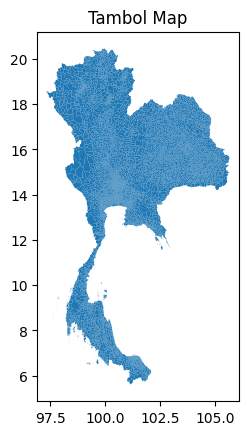

In [35]:
import geopandas as gpd
import matplotlib.pyplot as plt

# อ่าน shapefile
gdf = gpd.read_file("/content/drive/MyDrive/Lab1 GE234/Shapefile")

# ดูข้อมูลตัวอย่าง
print(gdf.head())

# plot แผนที่
gdf.plot()
plt.title("Tambol Map")
plt.show()



## **4. การแสดงผลข้อมูล**
### **4.1 สร้างกราฟด้วย Matplotlib**  5 คะแนน
สร้างกราฟแสดงประชากรของแต่ละประเทศในภูมิภาค ASEAN โดยให้นักศึกษาทดลองหาข้อมูลเอง
    

Total ASEAN Population (Sample Data): 685.95 Million
       Country  Population_Million  Year
0       Brunei                0.45  2024
1     Cambodia               17.50  2024
2    Indonesia              280.00  2024
3         Laos                7.70  2024
4     Malaysia               34.50  2024
5      Myanmar               54.80  2024
6  Philippines              118.00  2024
7    Singapore                6.00  2024
8     Thailand               66.50  2024
9      Vietnam              100.50  2024


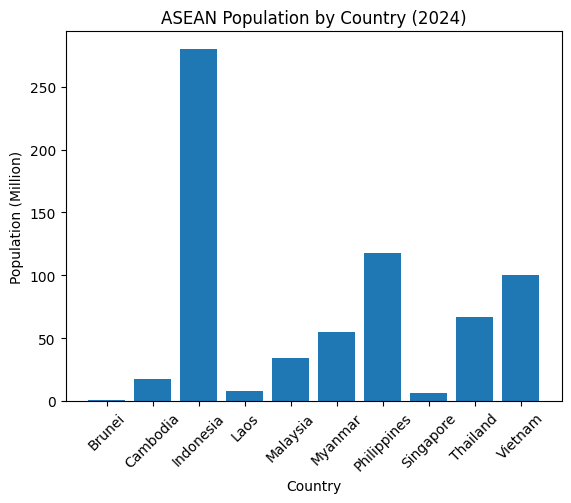

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# ตัวอย่างการจำลอง DataFrame ข้อมูลประชากรอาเซียน (ประมาณการ 2024-2025)
data = {
    'Country': ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia', 'Myanmar', 'Philippines', 'Singapore', 'Thailand', 'Vietnam'],
    'Population_Million': [0.45, 17.5, 280.0, 7.7, 34.5, 54.8, 118.0, 6.0, 66.5, 100.5],
    'Year': [2024]*10
}

df_asean = pd.DataFrame(data)

# ข้อมูลรวมทั้งหมด
total_population = df_asean['Population_Million'].sum()
print(f"Total ASEAN Population (Sample Data): {total_population} Million")
print(df_asean)

# -------- สร้างกราฟ --------
plt.figure()
plt.bar(df_asean['Country'], df_asean['Population_Million'])

plt.title("ASEAN Population by Country (2024)")
plt.xlabel("Country")
plt.ylabel("Population (Million)")
plt.xticks(rotation=45)

plt.show()



### **4.2 การรวมข้อมูลเชิงพื้นที่และตาราง**
รวมข้อมูล Shapefile กับข้อมูลประชากรเพื่อแสดงข้อมูลประชากรในแต่ละจังหวัด โดยให้นักศึกษาทดลองหาข้อมูลเอง
    

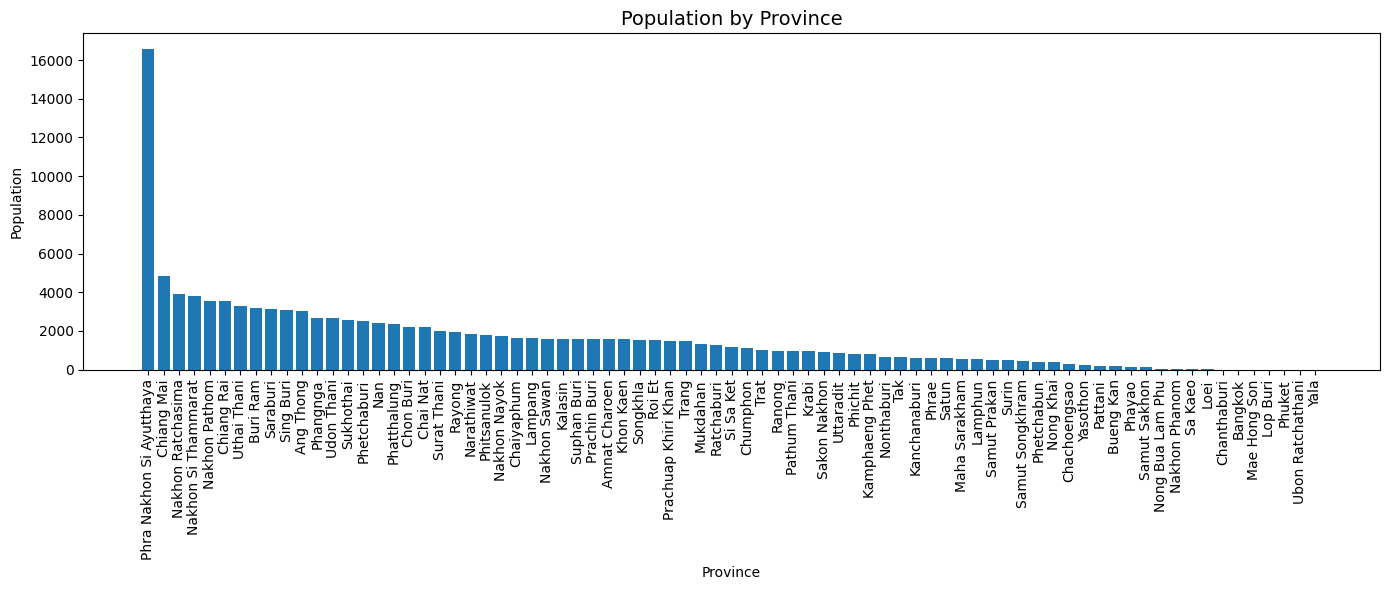

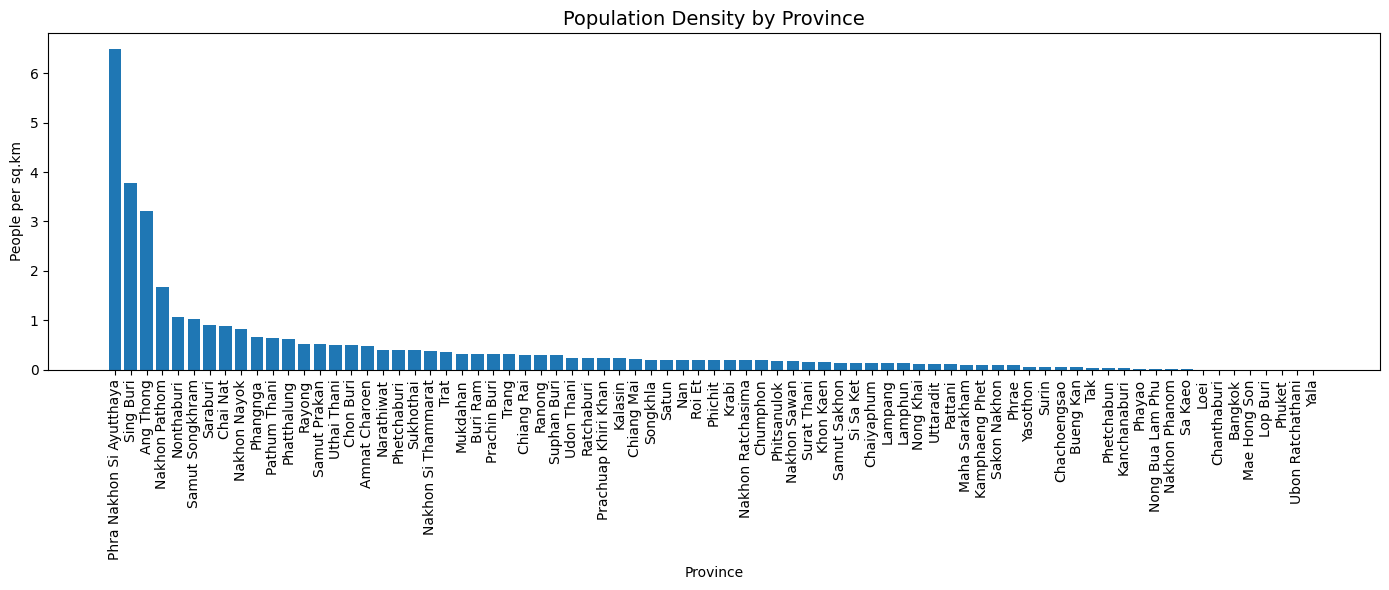

In [38]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. อ่าน shapefile
gdf = gpd.read_file(
    "/content/drive/MyDrive/Lab1 GE234/tha_admin_boundaries",
    layer="tha_admin3"
)

gdf["adm3_pcode"] = gdf["adm3_pcode"].astype(str).str.strip()

# 2. อ่าน CSV ประชากร
pop_df = pd.read_csv(
    "/content/drive/MyDrive/Lab1 GE234/stat_t67(in)_utf8.csv"
)

pop_df = pop_df.rename(columns={
    "รหัสตำบล": "adm3_pcode",
    "จำนวนประชากรทั้งหมด": "population"
})

# แปลงรหัสตำบล
pop_df["adm3_pcode"] = (
    pop_df["adm3_pcode"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(8)
    .str[:6]
)

pop_df["adm3_pcode"] = "TH" + pop_df["adm3_pcode"]

pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce")

# รวมประชากรระดับตำบล
pop_df = pop_df.groupby("adm3_pcode", as_index=False)["population"].sum()

# 3. merge
gdf = gdf.merge(pop_df, on="adm3_pcode", how="left")

gdf["population"] = pd.to_numeric(gdf["population"], errors="coerce")
gdf["area_sqkm"] = pd.to_numeric(gdf["area_sqkm"], errors="coerce")

# 4. รวมระดับจังหวัด
province_gdf = gdf.dissolve(
    by="adm1_name",
    aggfunc={
        "population": "sum",
        "area_sqkm": "sum"
    }
)

province_gdf["density"] = (
    province_gdf["population"] / province_gdf["area_sqkm"]
)

province_gdf = province_gdf.reset_index()

# 5. กราฟประชากรแต่ละจังหวัด
province_sorted = province_gdf.sort_values("population", ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(province_sorted["adm1_name"], province_sorted["population"])

plt.title("Population by Province", fontsize=14)
plt.xlabel("Province")
plt.ylabel("Population")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 6. กราฟความหนาแน่นประชากรต่อจังหวัด
province_sorted = province_gdf.sort_values("density", ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(province_sorted["adm1_name"], province_sorted["density"])

plt.title("Population Density by Province", fontsize=14)
plt.xlabel("Province")
plt.ylabel("People per sq.km")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



## **โจทย์สำหรับนักศึกษา** 15 คะแนน
1. ลองเพิ่มประเทศใหม่ใน DataFrame พร้อมคำนวณความหนาแน่นประชากร (5 คะแนน)
2. นำไฟล์ Shapefile ของพื้นที่อื่นมาแสดงผลใน GeoPandas (5 คะแนน)
3. ลองสร้างแผนที่ด้วยสีที่แตกต่างกันโดยใช้ค่าอื่น เช่น `area` หรือ `density` (5 คะแนน)

---

### **หมายเหตุ**
- ดาวน์โหลดข้อมูลจากแหล่ง Open Data เช่น [World Bank Open Data](https://data.worldbank.org) หรือ [Thailand Data Catalog](https://data.go.th)
- ใส่เครดิตแหล่งข้อมูลในรายงานของคุณ
    

In [39]:
import pandas as pd

# ข้อมูลเดิม + เพิ่มพื้นที่ (km²)
data = {
    'Country': [
        'Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia',
        'Myanmar', 'Philippines', 'Singapore', 'Thailand', 'Vietnam'
    ],
    'Population_Million': [0.45, 17.5, 280.0, 7.7, 34.5, 54.8, 118.0, 6.0, 66.5, 100.5],
    'Area_km2': [
        5765, 181035, 1904569, 236800, 330803,
        676578, 300000, 728, 513120, 331212
    ],
    'Year': [2024]*10
}

df = pd.DataFrame(data)

# เพิ่มญี่ปุ่น
japan = pd.DataFrame({
    'Country': ['Japan'],
    'Population_Million': [125.0],
    'Area_km2': [377975],
    'Year': [2024]
})

df = pd.concat([df, japan], ignore_index=True)

# คำนวณความหนาแน่น (คน / km²)
df["Population"] = df["Population_Million"] * 1_000_000
df["Density_per_km2"] = df["Population"] / df["Area_km2"]

print(df)


        Country  Population_Million  Area_km2  Year   Population  \
0        Brunei                0.45      5765  2024     450000.0   
1      Cambodia               17.50    181035  2024   17500000.0   
2     Indonesia              280.00   1904569  2024  280000000.0   
3          Laos                7.70    236800  2024    7700000.0   
4      Malaysia               34.50    330803  2024   34500000.0   
5       Myanmar               54.80    676578  2024   54800000.0   
6   Philippines              118.00    300000  2024  118000000.0   
7     Singapore                6.00       728  2024    6000000.0   
8      Thailand               66.50    513120  2024   66500000.0   
9       Vietnam              100.50    331212  2024  100500000.0   
10        Japan              125.00    377975  2024  125000000.0   

    Density_per_km2  
0         78.057242  
1         96.666390  
2        147.014889  
3         32.516892  
4        104.291678  
5         80.995835  
6        393.333333  
7      

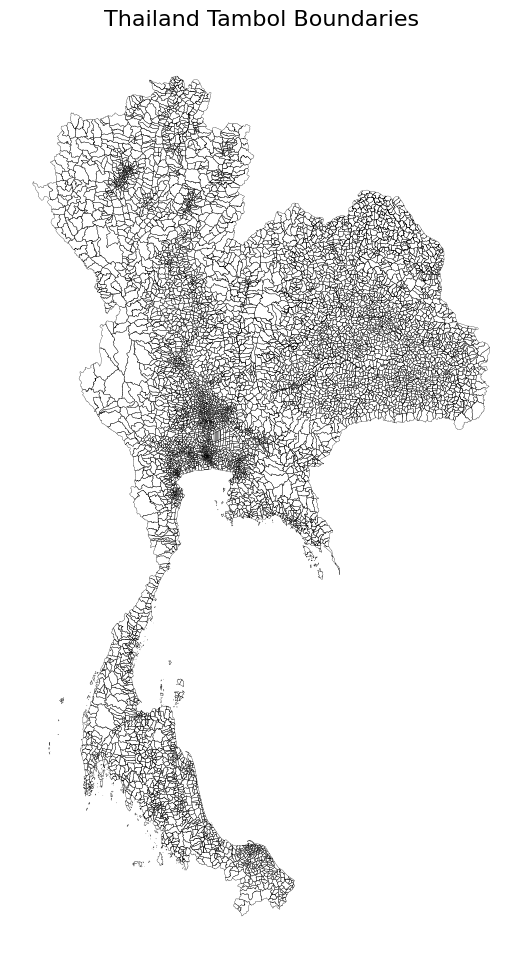

In [40]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file(
    "/content/drive/MyDrive/Lab1 GE234/tha_admin_boundaries",
    layer="tha_admin3"
)

fig, ax = plt.subplots(figsize=(10, 12))

gdf.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.2
)

ax.set_title("Thailand Tambol Boundaries", fontsize=16)
ax.axis("off")

plt.show()


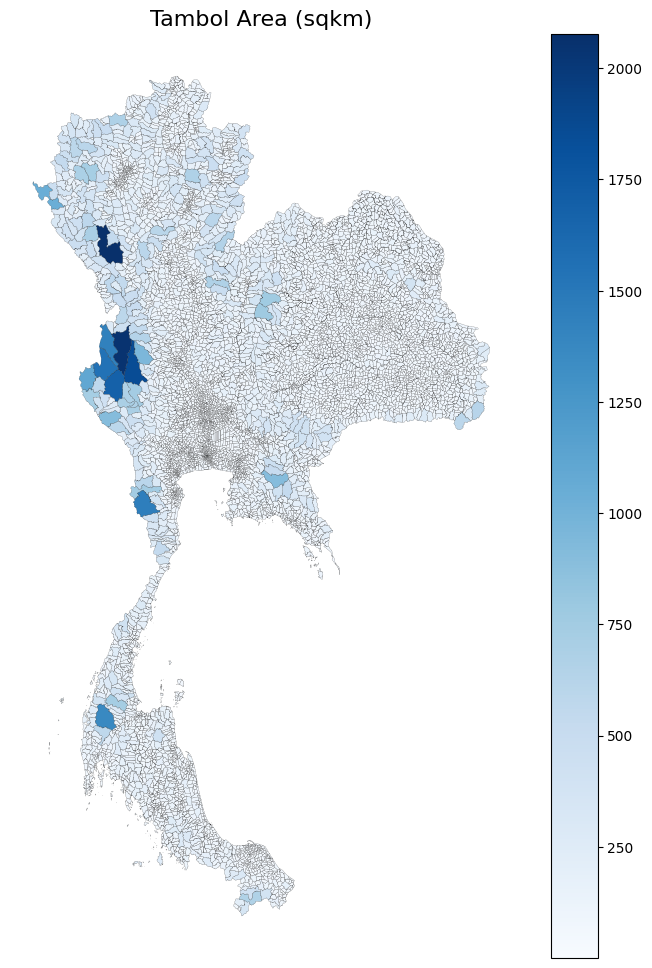

In [41]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. อ่าน shapefile
gdf = gpd.read_file(
    "/content/drive/MyDrive/Lab1 GE234/tha_admin_boundaries",
    layer="tha_admin3"
)

gdf["adm3_pcode"] = gdf["adm3_pcode"].astype(str).str.strip()

# 2. อ่าน CSV ประชากร
pop_df = pd.read_csv(
    "/content/drive/MyDrive/Lab1 GE234/stat_t67(in)_utf8.csv"
)

pop_df = pop_df.rename(columns={
    "รหัสตำบล": "adm3_pcode",
    "จำนวนประชากรทั้งหมด": "population"
})

# 3. แปลงรหัสตำบล
pop_df["adm3_pcode"] = (
    pop_df["adm3_pcode"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .str.zfill(8)
    .str[:6]
)

pop_df["adm3_pcode"] = "TH" + pop_df["adm3_pcode"]

pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce")

# รวมประชากรระดับตำบล
pop_df = pop_df.groupby("adm3_pcode", as_index=False)["population"].sum()

# 4. merge
gdf = gdf.merge(pop_df, on="adm3_pcode", how="left")

gdf["population"] = pd.to_numeric(gdf["population"], errors="coerce")
gdf["area_sqkm"] = pd.to_numeric(gdf["area_sqkm"], errors="coerce")

# 5. รวมเป็นระดับจังหวัด
province_gdf = gdf.dissolve(
    by="adm1_name",
    aggfunc={
        "population": "sum",
        "area_sqkm": "sum"
    }
)

province_gdf["density"] = (
    province_gdf["population"] / province_gdf["area_sqkm"]
)

province_gdf = province_gdf.reset_index()

fig, ax = plt.subplots(figsize=(10, 12))

gdf.plot(
    column="area_sqkm",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.1,
    ax=ax
)

ax.set_title("Tambol Area (sqkm)", fontsize=16)
ax.axis("off")

plt.show()

แหล่งข้อมูลทั้งหมด
https://stat.bora.dopa.go.th/new_stat/webPage/statByYear.php

https://data.humdata.org/dataset/cod-ab-tha